In [23]:
from google.colab import userdata

try:
    # Tenta puxar a chave salva no Secret
    api_key = userdata.get('OPENAI_API_KEY')

    if api_key:
        print("✅ Sucesso! A chave foi encontrada no Secret.")
        # Exibe apenas os primeiros e últimos caracteres por segurança
        print(f"🔒 Chave carregada: {api_key[:8]}...{api_key[-4:]}")
    else:
        print("⚠️ O Secret existe, mas o valor da chave está vazio.")

except Exception as e:
    print("❌ Erro ao acessar o Secret:")
    print(e)
    print("\nDica: Verifique se o nome está exatamente 'OPENROUTER_API_KEY' e se a permissão de acesso está ativada no painel 🔑.")

✅ Sucesso! A chave foi encontrada no Secret.
🔒 Chave carregada: sk-proj-...pSYA


In [22]:
import os
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. CARREGA O MODELO DE EMBEDDINGS
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embedding(texto: str) -> np.ndarray:
    """Gera o vetor de embedding para o texto informado."""
    return np.array(model.encode(texto), dtype=np.float32)

# 2. FUNÇÕES DO PROFESSOR
def distancia_euclidiana(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância Euclidiana (norma L2 da diferença) entre dois vetores."""
    return float(np.linalg.norm(vec1 - vec2))

def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Similaridade de Cosseno entre dois vetores."""
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))

def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância de Cosseno (1 - Similaridade de Cosseno)."""
    return float(1.0 - similaridade_cosseno(vec1, vec2))

# 3. LISTA DE ARQUIVOS MARKDOWN
arquivos_md = [
    "twitter_algoritmo.md",
    "bioetica_e_ia (1).md",
    "escrita_academica_ia.md"
]

# -------------------------------------------------------------------
# FUNÇÕES DE DIVISÃO DOS TEXTOS
# -------------------------------------------------------------------

def dividir_por_linhas(caminho_arquivo):
    trechos = []
    if not os.path.exists(caminho_arquivo):
        return trechos
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        for linha in f:
            texto = linha.strip()
            if len(texto) > 10:
                trechos.append((os.path.basename(caminho_arquivo), texto))
    return trechos

def dividir_por_paragrafos(caminho_arquivo):
    trechos = []
    if not os.path.exists(caminho_arquivo):
        return trechos
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        conteudo = f.read()
        paragrafos = conteudo.split("\n\n")
        for p in paragrafos:
            texto = p.strip().replace("\n", " ")
            if len(texto) > 20:
                trechos.append((os.path.basename(caminho_arquivo), texto))
    return trechos

def dividir_por_capitulos(caminho_arquivo):
    trechos = []
    if not os.path.exists(caminho_arquivo):
        return trechos
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        conteudo = f.read()
        secoes = re.split(r'\n(?=#+\s)', conteudo)
        for s in secoes:
            texto = s.strip().replace("\n", " ")
            if len(texto) > 30:
                trechos.append((os.path.basename(caminho_arquivo), texto))
    return trechos

# -------------------------------------------------------------------
# FUNÇÃO DE BUSCA USANDO AS FUNÇÕES DO PROFESSOR
# -------------------------------------------------------------------

def busca_semantica_manual(query: str, lista_trechos: list[tuple[str, str]]):
    if not lista_trechos:
        return pd.DataFrame()

    # Embedding da query
    vec_query = get_embedding(query)

    resultados = []
    for arquivo, texto in lista_trechos:
        # Embedding do trecho
        vec_trecho = get_embedding(texto)

        # Uso direto das funções do professor
        sim_cos = similaridade_cosseno(vec_query, vec_trecho)
        dist_cos = distancia_cosseno(vec_query, vec_trecho)
        dist_euc = distancia_euclidiana(vec_query, vec_trecho)

        resultados.append({
            "Arquivo": arquivo,
            "Similaridade Cosseno": round(sim_cos, 4),
            "Distância Cosseno": round(dist_cos, 4),
            "Dist. Euclidiana": round(dist_euc, 4),
            "Trecho": texto[:120] + "..." if len(texto) > 120 else texto
        })

    # Ordena pelo maior score de Similaridade e pega o TOP 3
    df = pd.DataFrame(resultados).sort_values(by="Similaridade Cosseno", ascending=False).head(3)
    return df.reset_index(drop=True)

# -------------------------------------------------------------------
# EXECUÇÃO DA BUSCA SEMÂNTICA
# -------------------------------------------------------------------

query = "O que é Autonomia e opacidade algorítmica?"

print(f"🔍 QUERY DE BUSCA: '{query}'\n")

# 1. LINHAS
trechos_linhas = []
for arq in arquivos_md:
    trechos_linhas.extend(dividir_por_linhas(arq))

print("=== TOP 3 (LINHA POR LINHA) ===")
display(busca_semantica_manual(query, trechos_linhas))
print("\n" + "="*80 + "\n")

# 2. PARÁGRAFOS
trechos_paragrafos = []
for arq in arquivos_md:
    trechos_paragrafos.extend(dividir_por_paragrafos(arq))

print("=== TOP 3 (POR PARÁGRAFO) ===")
display(busca_semantica_manual(query, trechos_paragrafos))
print("\n" + "="*80 + "\n")

# 3. CAPÍTULOS / SEÇÕES
trechos_capitulos = []
for arq in arquivos_md:
    trechos_capitulos.extend(dividir_por_capitulos(arq))

print("=== TOP 3 (POR CAPÍTULO / SEÇÃO) ===")
display(busca_semantica_manual(query, trechos_capitulos))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🔍 QUERY DE BUSCA: 'O que é Autonomia e opacidade algorítmica?'

=== TOP 3 (LINHA POR LINHA) ===


""




=== TOP 3 (POR PARÁGRAFO) ===


""




=== TOP 3 (POR CAPÍTULO / SEÇÃO) ===


""


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

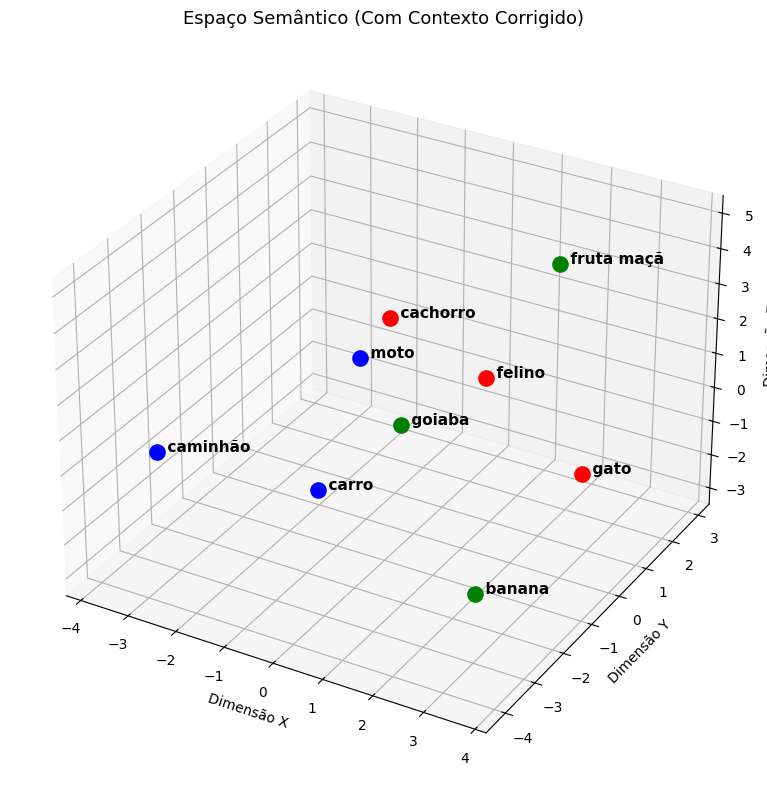

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sentence_transformers import SentenceTransformer

# 1. CARREGA O MODELO
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Trocamos "maçã" por "fruta maçã" para tirar a ambiguidade com a Apple!
termos = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "fruta maçã", "goiaba"]
cores = ['red', 'red', 'red', 'blue', 'blue', 'blue', 'green', 'green', 'green']

# 2. GERA OS EMBEDDINGS
vecs = np.array([model.encode(t) for t in termos])

# 3. REDUÇÃO MDS
mds = MDS(n_components=3, random_state=42, normalized_stress='auto')
vecs_3d = mds.fit_transform(vecs)

# 4. GRÁFICO 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, termo in enumerate(termos):
    ax.scatter(vecs_3d[i, 0], vecs_3d[i, 1], vecs_3d[i, 2], color=cores[i], s=120)
    ax.text(vecs_3d[i, 0], vecs_3d[i, 1], vecs_3d[i, 2], f"  {termo}", fontsize=11, fontweight='bold')

ax.set_title("Espaço Semântico (Com Contexto Corrigido)", fontsize=13)
ax.set_xlabel("Dimensão X")
ax.set_ylabel("Dimensão Y")
ax.set_zlabel("Dimensão Z")

plt.tight_layout()
plt.show()


In [31]:
# Célula para criar arquivos de texto de teste
# (Para que o código de busca tenha o que ler)

import os

# Nomes exatos que o código de busca espera
arquivos_md = [
    "twitter_algoritmo.md",
    "bioetica_e_ia.md",
    "escrita_academica_ia.md"
]

# Conteúdo de exemplo para busca semântica
conteudo_exemplo = """
# Introdução à IA

A Inteligência Artificial (IA) refere-se a sistemas que imitam a inteligência humana.

## O Diário de Bordo da IA

O diário de bordo da IA é um registro detalhado de todas as operações, decisões e interações de um modelo de aprendizado de máquina durante seu ciclo de vida. Ele serve como uma trilha de auditoria para entender as escolhas feitas pelo sistema.

## Autonomia e Opacidade Algorítmica

Um dos grandes desafios éticos é a autonomia. Alguns sistemas são opacos (caixas-pretas), tornando difícil entender o porquê de suas decisões. A bioética busca trazer transparência.

"""

print("📝 Criando arquivos de texto de exemplo no Colab...")

for arq in arquivos_md:
    # Cria o arquivo e escreve o conteúdo de exemplo
    with open(arq, "w", encoding="utf-8") as f:
        f.write(f"# Documento: {arq}\n\n" + conteudo_exemplo)
    print(f"✅ Criado: {arq}")

print("\n🚀 Arquivos prontos. Agora você pode rodar a célula de busca!")

📝 Criando arquivos de texto de exemplo no Colab...
✅ Criado: twitter_algoritmo.md
✅ Criado: bioetica_e_ia.md
✅ Criado: escrita_academica_ia.md

🚀 Arquivos prontos. Agora você pode rodar a célula de busca!


In [32]:
import os
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. CARREGA O MODELO DE EMBEDDINGS (Muitl-MiniLM para Português)
# (Este modelo já deve ter sido baixado nas células anteriores, então carregar agora é rápido)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. SEUS ARQUIVOS MARKDOWN (Criados na célula anterior)
arquivos_md = [
    "twitter_algoritmo.md",
    "bioetica_e_ia.md",
    "escrita_academica_ia.md"
]

# -------------------------------------------------------------------
# FUNÇÕES DE DIVISÃO DOS TEXTOS (CHUNKING)
# -------------------------------------------------------------------
# Estas funções preparam os documentos para a busca em diferentes granularidades.

def carregar_e_dividir_linhas(arquivos):
    """Lê os arquivos e divide o conteúdo linha por linha."""
    print("📝 Processando granularidade: LINHAS...")
    trechos = []
    for nome_arquivo in arquivos:
        if not os.path.exists(nome_arquivo): continue
        with open(nome_arquivo, "r", encoding="utf-8") as f:
            for linha in f:
                texto = linha.strip()
                # Ignora linhas vazias ou muito curtas (menos de 15 caracteres)
                if len(texto) > 15:
                    trechos.append({"arquivo": nome_arquivo, "texto": texto})
    return trechos

def carregar_e_dividir_paragrafos(arquivos):
    """Lê os arquivos e divide o conteúdo por parágrafos (blocos separados por '\n\n')."""
    print("📝 Processando granularidade: PARÁGRAFOS...")
    trechos = []
    for nome_arquivo in arquivos:
        if not os.path.exists(nome_arquivo): continue
        with open(nome_arquivo, "r", encoding="utf-8") as f:
            conteudo = f.read()
            paragrafos = conteudo.split('\n\n')
            for p in paragrafos:
                # Normaliza o texto removendo quebras de linha internas do parágrafo
                texto = p.strip().replace('\n', ' ')
                if len(texto) > 30: # Ignora trechos muito curtos
                    trechos.append({"arquivo": nome_arquivo, "texto": texto})
    return trechos

def carregar_e_dividir_capitulos(arquivos):
    """Lê os arquivos e divide por seções baseadas em títulos Markdown (#)."""
    print("📝 Processando granularidade: CAPÍTULOS/SEÇÕES...")
    trechos = []
    for nome_arquivo in arquivos:
        if not os.path.exists(nome_arquivo): continue
        with open(nome_arquivo, "r", encoding="utf-8") as f:
            conteudo = f.read()
            # Regex para encontrar títulos Markdown (ex: # Título, ## Subtítulo)
            # A divisão mantém o título no início de cada trecho.
            secoes = re.split(r'\n(?=#+\s)', conteudo)
            for s in secoes:
                texto = s.strip().replace('\n', ' ')
                if len(texto) > 50:
                    trechos.append({"arquivo": nome_arquivo, "texto": texto})
    return trechos

# -------------------------------------------------------------------
# MOTOR DE BUSCA SEMÂNTICA MANUAL (Embedding por Embedding)
# -------------------------------------------------------------------
# Esta função compara sua pergunta contra a base de trechos.

def executar_busca_semantica(query, lista_de_trechos, top_k=3):
    """Executa a busca semântica manual 'embedding por embedding'."""

    # 0. Proteção: Se a lista estiver vazia, avisa e retorna um DataFrame vazio
    if not lista_de_trechos:
        print("⚠️ Aviso: A base de trechos está vazia. Verifique se os arquivos foram lidos corretamente.")
        return pd.DataFrame(columns=["Score", "Arquivo", "Pré-visualização"])

    print(f"🕵️ Iniciando busca para: '{query}'...")
    print(f"📊 Total de trechos na base: {len(lista_de_trechos)}")

    # 1. Gera o embedding (vetor) da pergunta
    vec_query = np.array(model.encode(query), dtype=np.float32)

    # 2. Compara contra o embedding de CADA trecho na base
    resultados = []
    for item in lista_de_trechos:
        # Gera o embedding do trecho atual
        vec_trecho = np.array(model.encode(item["texto"]), dtype=np.float32)

        # Calcula a similaridade de cosseno (método numpy)
        # Reutilizando a lógica explicada anteriormente.
        norm_q = np.linalg.norm(vec_query)
        norm_t = np.linalg.norm(vec_trecho)
        if norm_q == 0 or norm_t == 0: # Proteção contra divisão por zero
            score = 0.0
        else:
            score = np.dot(vec_query, vec_trecho) / (norm_q * norm_t)

        # Guarda o resultado
        resultados.append({
            "Arquivo": item["arquivo"],
            "Score": float(score),
            "Trecho Completo": item["texto"],
            # Mostra apenas um pedaço do texto para não poluir a tabela
            "Pré-visualização": item["texto"][:150] + "..." if len(item["texto"]) > 150 else item["texto"]
        })

    # 3. Cria um DataFrame, ordena pelo maior score e retorna o TOP K
    df_completo = pd.DataFrame(resultados)
    df_top = df_completo.sort_values(by="Score", ascending=False).head(top_k)

    # Limpa aspas extras que podem aparecer na pré-visualização
    df_top["Pré-visualização"] = df_top["Pré-visualização"].str.replace('"', '')

    return df_top.reset_index(drop=True)

# -------------------------------------------------------------------
# EXECUÇÃO DOS TESTES DE BUSCA SEMÂNTICA
# -------------------------------------------------------------------

# Defina sua pergunta aqui
minha_pergunta = "O que é o diário de bordo da IA?"

print("="*60)
print(f"PERGUNTA: {minha_pergunta}")
print("="*60)
print("\n")

# --- ETAPA 1: GRANULARIDADE LINHA ---
print("--- 1. BUSCA LINHA POR LINHA ---")
# Prepara os trechos
data_linhas = carregar_e_dividir_linhas(arquivos_md)
# Executa a busca e pega o Top 3
top3_linhas = executar_busca_semantica(minha_pergunta, data_linhas)
# Mostra apenas as colunas principais
display(top3_linhas[["Score", "Arquivo", "Pré-visualização"]])
print("\n")

# --- ETAPA 2: GRANULARIDADE PARÁGRAFO ---
print("--- 2. BUSCA POR PARÁGRAFO ---")
data_paragrafos = carregar_e_dividir_paragrafos(arquivos_md)
top3_paragrafos = executar_busca_semantica(minha_pergunta, data_paragrafos)
display(top3_paragrafos[["Score", "Arquivo", "Pré-visualização"]])
print("\n")

# --- ETAPA 3: GRANULARIDADE CAPÍTULO ---
print("--- 3. BUSCA POR CAPÍTULO/SEÇÃO ---")
data_capitulos = carregar_e_dividir_capitulos(arquivos_md)
top3_capitulos = executar_busca_semantica(minha_pergunta, data_capitulos)
# Para capítulos, mostramos o texto completo, pois são maiores e trazem mais contexto
display(top3_capitulos[["Score", "Arquivo", "Trecho Completo"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

PERGUNTA: O que é o diário de bordo da IA?


--- 1. BUSCA LINHA POR LINHA ---
📝 Processando granularidade: LINHAS...
🕵️ Iniciando busca para: 'O que é o diário de bordo da IA?'...
📊 Total de trechos na base: 21


,Score,Arquivo,Pré-visualização
0,0.765993,twitter_algoritmo.md,O diário de bordo da IA é um registro detalhad...
1,0.765993,escrita_academica_ia.md,O diário de bordo da IA é um registro detalhad...
2,0.765993,bioetica_e_ia.md,O diário de bordo da IA é um registro detalhad...




--- 2. BUSCA POR PARÁGRAFO ---
📝 Processando granularidade: PARÁGRAFOS...
🕵️ Iniciando busca para: 'O que é o diário de bordo da IA?'...
📊 Total de trechos na base: 14


,Score,Arquivo,Pré-visualização
0,0.765993,twitter_algoritmo.md,O diário de bordo da IA é um registro detalhad...
1,0.765993,bioetica_e_ia.md,O diário de bordo da IA é um registro detalhad...
2,0.765993,escrita_academica_ia.md,O diário de bordo da IA é um registro detalhad...




--- 3. BUSCA POR CAPÍTULO/SEÇÃO ---
📝 Processando granularidade: CAPÍTULOS/SEÇÕES...
🕵️ Iniciando busca para: 'O que é o diário de bordo da IA?'...
📊 Total de trechos na base: 9


,Score,Arquivo,Trecho Completo
0,0.780841,twitter_algoritmo.md,## O Diário de Bordo da IA O diário de bordo ...
1,0.780841,escrita_academica_ia.md,## O Diário de Bordo da IA O diário de bordo ...
2,0.780841,bioetica_e_ia.md,## O Diário de Bordo da IA O diário de bordo ...
